# Interacting with prop datasets

To know
- Distribution of lengths -> compute cut-offs
- Distribution of splits -> compute splits

In [1]:
from multiprocessing import Pool

import datasets
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm

from prop import *

datasets.disable_caching()

In [2]:
# ds_path = full_text_ds_path
ds_path = '/n/home09/wlt/scratch/data/prop_gen/data/hf_php_enum_text_32768'
ds = datasets.load_from_disk(ds_path)
ds

DatasetDict({
    False_71: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 32
    })
    True_96: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 512
    })
    False_96: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 64
    })
    True_97: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 512
    })
    False_97: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 64
    })
    True_144: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 128
    })
    False_144: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 528
    })
    False_126: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 

In [3]:
np.sum([len(d) for d in ds.values()])

np.int64(179023)

In [4]:
ds.cleanup_cache_files()

{'False_71': 0,
 'True_96': 0,
 'False_96': 0,
 'True_97': 0,
 'False_97': 0,
 'True_144': 0,
 'False_144': 0,
 'False_126': 0,
 'False_127': 0,
 'True_146': 0,
 'True_145': 0,
 'False_129': 0,
 'False_128': 0,
 'True_147': 0,
 'True_148': 0,
 'True_149': 0,
 'True_143': 0,
 'False_143': 0,
 'False_85': 0,
 'False_174': 0,
 'True_86': 0,
 'False_86': 0,
 'False_187': 0,
 'False_190': 0,
 'False_211': 0,
 'False_212': 0,
 'True_87': 0,
 'False_87': 0,
 'False_214': 0,
 'False_213': 0,
 'False_216': 0,
 'False_215': 0,
 'False_279': 0,
 'True_89': 0,
 'False_89': 0,
 'True_90': 0,
 'False_90': 0,
 'False_108': 0,
 'False_110': 0,
 'False_325': 0,
 'True_74': 0,
 'True_75': 0,
 'False_75': 0,
 'False_170': 0,
 'False_172': 0,
 'True_58': 0,
 'False_58': 0,
 'True_59': 0,
 'False_164': 0,
 'False_165': 0,
 'False_166': 0,
 'False_167': 0,
 'False_168': 0,
 'False_188': 0,
 'False_61': 0,
 'False_62': 0,
 'True_91': 0,
 'False_91': 0,
 'True_83': 0,
 'False_83': 0,
 'False_84': 0,
 'False_1

Text(0, 0.5, 'number of examples')

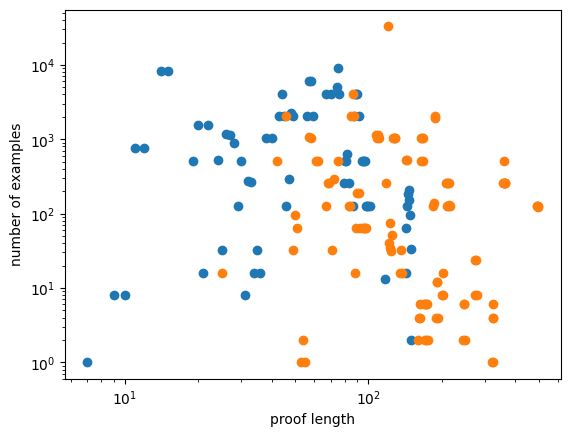

In [5]:
t_vals = []
f_vals = []
a_vals = {}

for k, v in ds.items():
    name, num = k.split('_')

    if name == 'True':
        t_vals.append((int(num), len(v)))
    else:
        f_vals.append((int(num), len(v)))
    
    if int(num) not in a_vals:
        a_vals[int(num)] = len(v)
    else:
        a_vals[int(num)] += len(v)
        

a_vals = list(a_vals.items())

# <codecell>
import matplotlib.pyplot as plt

t_idx, t_lens = np.array(t_vals).T
f_idx, f_lens = np.array(f_vals).T
a_idx, a_lens = np.array(a_vals).T

plt.scatter(t_idx, t_lens)
plt.scatter(f_idx, f_lens)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('proof length')
plt.ylabel('number of examples')

In [6]:
print(f_idx)
print(f_lens)

[ 71  96  97 144 126 127 129 128 143  85 174  86 187 190 211 212  87 214
 213 216 215 279  89  90 108 110 325  75 170 172  58 164 165 166 167 168
 188  61  62  91  83  84 122 123 210 358 359 360 361 362 363 364  72  69
  50  95  88  98 209 184 186  25  57  42 118 120  46  49  67 107 109 495
 493  68 121 137 163 169 171 136 193 275  92 125  51 491 497 135 191 192
 273 124 201 162 173 324 277 323 203 247 202 248 161 246 160  55 245 322
 175 326  54  53]
[   32    64    64   528  1038  1024  1024  1024   528  2048     6  4096
  2062     4   128   128  2048   260   258   128   130     8    64   192
  1024  1024     4   512     6     2  1024   512  1024  1024  1024   514
  1916   512   512   192   128   128    74    34   256   256   256   256
   512   256   256   256   288   256    96    64    16    64   256   128
   140    16  1056   512   256 33024  2048    32   128  1152  1152   128
   128   256    40    16     4     6     2    32     4    24    64    51
    64   128   123    16    12   

prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    21     86     44
 0.4:    49    118     69
 0.5:    57    118     75
 0.6:    67    118     87
 0.8:    80    128    118
 0.9:    88    186    125
0.95:    90    210    167


Text(0, 0.5, 'cumulative proportion of examples')

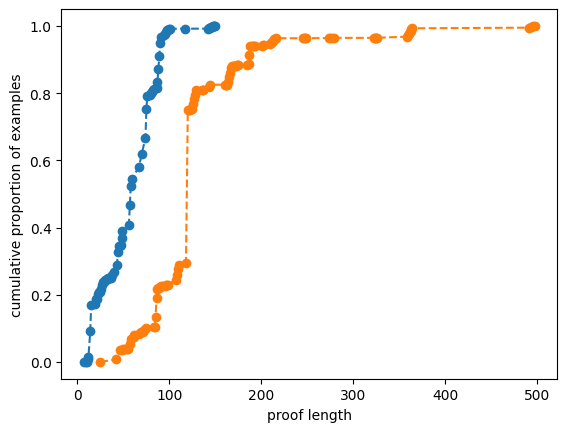

In [7]:
t_sort_idx = np.argsort(t_idx)
t_cum = np.cumsum(t_lens[t_sort_idx]) / np.sum(t_lens)

f_sort_idx = np.argsort(f_idx)
f_cum = np.cumsum(f_lens[f_sort_idx]) / np.sum(f_lens)

a_sort_idx = np.argsort(a_idx)
a_cum = np.cumsum(a_lens[a_sort_idx]) / np.sum(a_lens)

plt.plot(np.sort(t_idx), t_cum, 'o--')
plt.plot(np.sort(f_idx), f_cum, 'o--')

props = [0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.95]

t_idxs = []
f_idxs = []
a_idxs = []

for p in props:
    idx = np.sum(t_cum < p) - 1
    t_idxs.append(t_idx[t_sort_idx][idx].item())
    
    idx = np.sum(f_cum < p) - 1
    f_idxs.append(f_idx[f_sort_idx][idx].item())
    
    idx = np.sum(a_cum < p) - 1
    a_idxs.append(a_idx[a_sort_idx][idx].item())

print(f'prop | t_idx | f_idx | a_idx')
print('------------------------------')
for prop, t, f, a in zip(props, t_idxs, f_idxs, a_idxs):
    print(f'{prop:4}: {t:5} {f:6} {a:6}')

plt.xlabel('proof length')
plt.ylabel('cumulative proportion of examples')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-Coder-7B')

def to_toks(ex):
    inp_and_proof_toks = tokenizer(ex['prompt'] + ex['completion'], return_attention_mask=False)

    return {
        'tok_len': len(inp_and_proof_toks['input_ids']),
    }

ds = ds.map(to_toks, batched=False, num_proc=24)

In [ ]:
def slice_dataset(ds, start, stop):
    all_ds = []

    for key in ds.keys():
        name, i = key.split('_')
        i = int(i)

        if start <= i < stop:
            all_ds.append(ds[key].remove_columns('ops'))

    if len(all_ds) == 0:
        return ds[key].select(range(0))  # empty dataset

    return datasets.concatenate_datasets(all_ds)

train_ds = slice_dataset(ds, 0, 18)
test_ds = slice_dataset(ds, 19, np.inf)

In [ ]:
def get_len(ex):
    return ex['tok_len']

with Pool(24) as pool:
    train_lens = pool.map(get_len, train_ds)
    test_lens = pool.map(get_len, test_ds)

In [ ]:
plt.hist(train_lens, bins=50)
np.quantile(train_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

In [ ]:
plt.hist(test_lens, bins=50)
np.quantile(test_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

In [ ]:
test_lens = np.array(test_lens)
np.mean(test_lens < 32_768)

In [ ]:
train_lens = np.array(train_lens)
np.mean(train_lens < 8192)

In [ ]:
(np.sum(train_lens) + np.sum(test_lens)) / 1e9

## Length distributions for different datasets

Full
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2      1      2
 0.4:     3      4      3
 0.5:     4      4      4
 0.6:     5      5      5
 0.8:     7      8      7
 0.9:     8     11     10
0.95:    11     14     13
```


Imply
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2     11      3
 0.4:     3     14      5
 0.5:     3     17      9
 0.6:     3     20     12
 0.8:     5     28     21
 0.9:     8     41     29
0.95:    12     56     42
```


Or
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     3     13      3
 0.4:     5     13      5
 0.5:     6     13      6
 0.6:     7     13      7
 0.8:    10     13     10
 0.9:    12     13     13
0.95:    13     13     14
```

Or (par)
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     6      9      7
 0.4:    11     19     14
 0.5:    14     23     18
 0.6:    18     29     24
 0.8:    28     39     36
 0.9:    36     45     44
0.95:    42     49     48
```


PHP
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    15     55     58
 0.4:    36     55     58
 0.5:    42     71     58
 0.6:    42     71     84
 0.8:    80     92     92
 0.9:    82    100     92
0.95:   143    104    110
```

PHP (par)
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    20     66     33
 0.4:    31    104     59
 0.5:    36    122     76
 0.6:    44    147     97
 0.8:    64    208    169
 0.9:    82    268    220
0.95:    91    306    277
```

PHP (enum)

```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    21     86     44
 0.4:    49    118     69
 0.5:    57    118     75
 0.6:    67    118     87
 0.8:    80    128    118
 0.9:    88    186    125
0.95:    90    210    167
```

### Length quantiles

TODO: can shorten context length during training for these two

Full:

3630455 points, 1.4 billion tokens

max train length < 512
max test length <~ 2048

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99]
[ 189.,  370.,  537.,  688.,  783., 1144.]
```


Implies:
11015905 points, 11.6 billion tokens

max train length < 1024
max test length <~ 16,384

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99, max]
[ 275.,  634., 1126., 2117., 3125., 7494., 94357]
```

Or (par):
8657010 points, 78.5 billion tokens

max train length <~ 8192
max test length <~ 32,768


PHP (par)
168702 points, 2.5 billion tokens
max train/test length <~ 32,768

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99, max]
[12732., 18542., 25357., 29543., 31087., 32366., 32751.]
```

